# Entraînement du Modèle — Recommandation Top-3 des Cultures
## Dataset : FAO / IITA / IRAD / CIRAD | Unités N, P, K : mg/kg

**Pipeline :**
1. Chargement du dataset `research_based_dataset.csv`
2. Pré-traitement et split train/test
3. Entraînement d'un `RandomForestClassifier` (200 arbres)
4. Évaluation : validation croisée 10-fold, accuracy, rapport de classification
5. Prédiction **Top-3** via `predict_proba` → les 3 meilleures cultures par sol
6. Sauvegarde du modèle dans `model/top3_crop_model.pkl`

In [1]:
import pickle
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
os.makedirs('model', exist_ok=True)

RANDOM_SEED = 42
print('Librairies chargées.')

Librairies chargées.


## 1. Chargement du Dataset

In [2]:
df = pd.read_csv('data/research_based_dataset.csv')

print(f'Dimensions  : {df.shape}')
print(f'Cultures    : {df["label"].nunique()}')
print(f'Colonnes    : {list(df.columns)}')
print()
print('Distribution des classes :')
print(df['label'].value_counts())
df.head()

Dimensions  : (7500, 8)
Cultures    : 15
Colonnes    : ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']

Distribution des classes :
label
riz                500
mais               500
sorgho             500
mil                500
haricot            500
soja               500
niebe              500
manioc             500
igname             500
taro               500
cacao              500
cafe_robusta       500
cafe_arabica       500
palmier_a_huile    500
banane_plantain    500
Name: count, dtype: int64


,N,P,K,temperature,humidity,ph,rainfall,label
0,82.47,34.01,41.96,27.99,73.12,5.31,1275.51,riz
1,111.97,27.02,41.24,22.21,89.40,6.66,1476.04,riz
2,70.91,18.67,29.13,27.25,78.64,5.58,1995.41,riz
3,68.37,20.84,30.99,26.56,85.70,5.40,1868.50,riz
4,95.54,15.93,38.23,23.71,71.30,6.90,2455.32,riz


## 2. Pré-traitement

In [3]:
FEATURES = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
TARGET   = 'label'

X = df[FEATURES].values
y_raw = df[TARGET].values

# Encodage des labels
le = LabelEncoder()
y = le.fit_transform(y_raw)
classes = le.classes_
print(f'Classes encodées ({len(classes)}) :')
for i, c in enumerate(classes):
    print(f'  {i:2d} → {c}')

# Split stratifié 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)
print(f'\nTrain : {X_train.shape}  |  Test : {X_test.shape}')

Classes encodées (15) :
   0 → banane_plantain
   1 → cacao
   2 → cafe_arabica
   3 → cafe_robusta
   4 → haricot
   5 → igname
   6 → mais
   7 → manioc
   8 → mil
   9 → niebe
  10 → palmier_a_huile
  11 → riz
  12 → soja
  13 → sorgho
  14 → taro

Train : (6000, 7)  |  Test : (1500, 7)


## 3. Entraînement du Modèle

In [4]:
clf = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
clf.fit(X_train, y_train)
print('✔ Modèle entraîné.')

✔ Modèle entraîné.


## 4. Évaluation du Modèle

In [5]:
cv_scores = cross_val_score(clf, X, y, cv=10, scoring='accuracy', n_jobs=-1)
print(f'Validation croisée (10-fold) :')
print(f'  Accuracy moyenne : {cv_scores.mean() * 100:.2f} %')
print(f'  Écart-type       : {cv_scores.std()  * 100:.2f} %')
print(f'  Scores           : {[round(s*100,2) for s in cv_scores]}')

Validation croisée (10-fold) :
  Accuracy moyenne : 86.20 %
  Écart-type       : 0.91 %
  Scores           : [85.47, 84.93, 84.4, 86.53, 86.67, 86.93, 86.27, 86.4, 87.2, 87.2]


In [6]:
y_pred = clf.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
print(f'Accuracy sur le jeu de test : {test_acc * 100:.2f} %\n')
print('Rapport de classification :')
print(classification_report(y_test, y_pred, target_names=classes))

Accuracy sur le jeu de test : 85.93 %

Rapport de classification :


                 precision    recall  f1-score   support

banane_plantain       0.98      0.93      0.95       100
          cacao       0.75      0.86      0.80       100
   cafe_arabica       0.93      0.97      0.95       100
   cafe_robusta       0.79      0.83      0.81       100
        haricot       0.89      0.95      0.92       100
         igname       0.64      0.68      0.66       100
           mais       1.00      1.00      1.00       100
         manioc       0.75      0.70      0.73       100
            mil       0.86      0.92      0.89       100
          niebe       0.82      0.84      0.83       100
palmier_a_huile       0.86      0.81      0.84       100
            riz       1.00      1.00      1.00       100
           soja       0.97      0.90      0.93       100
         sorgho       0.84      0.76      0.80       100
           taro       0.84      0.74      0.79       100

       accuracy                           0.86      1500
      macro avg       0.86   

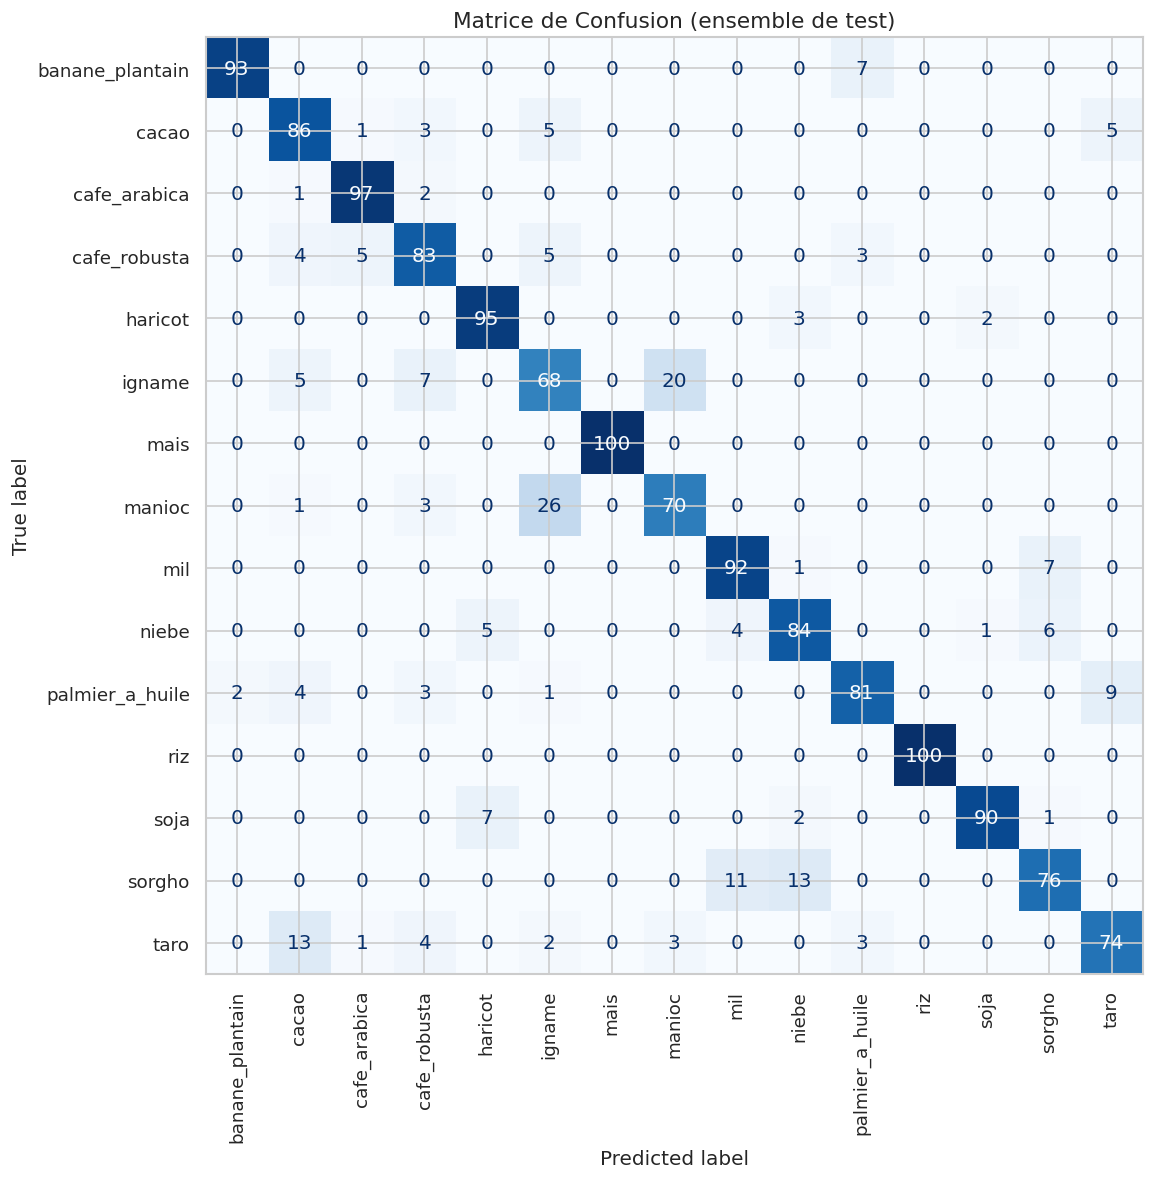

In [7]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(12, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(ax=ax, xticks_rotation='vertical', colorbar=False, cmap='Blues')
ax.set_title('Matrice de Confusion (ensemble de test)', fontsize=13)
plt.tight_layout()
plt.show()

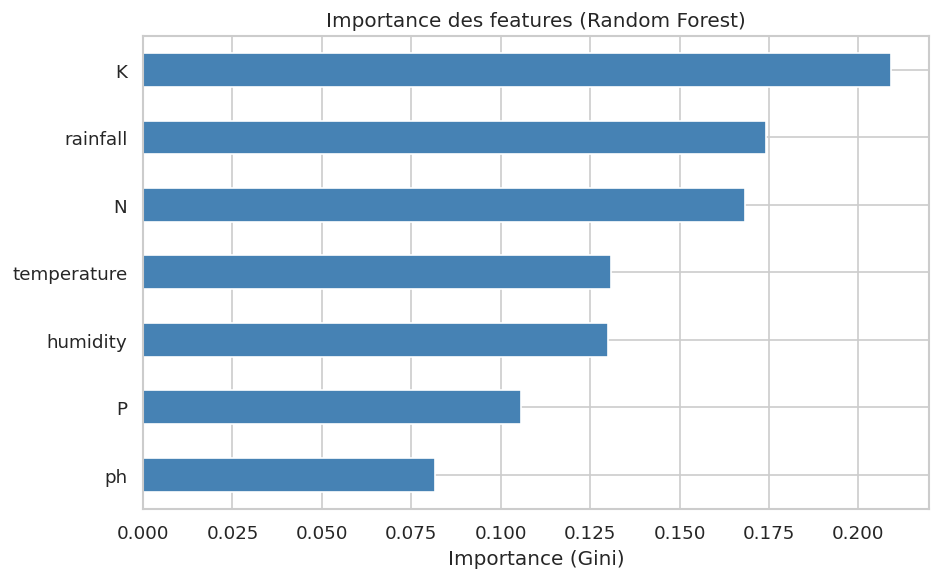

In [8]:
importances = pd.Series(clf.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Importance des features (Random Forest)')
ax.set_xlabel('Importance (Gini)')
plt.tight_layout()
plt.show()

## 5. Prédiction Top-3 Cultures

Pour un profil de sol donné, on utilise `predict_proba` pour obtenir la probabilité de chaque culture, puis on sélectionne les **3 meilleures**.

In [9]:
def predict_top3(model, label_encoder, soil_profile: dict, top_k: int = 3):
    """
    Prédit les top_k meilleures cultures pour un profil de sol donné.

    Args:
        model          : RandomForestClassifier entraîné.
        label_encoder  : LabelEncoder utilisé lors de l'entraînement.
        soil_profile   : dict avec clés [N, P, K, temperature, humidity, ph, rainfall].
        top_k          : nombre de recommandations (défaut 3).

    Returns:
        List[dict] : [{rank, culture, probabilite}, ...]
    """
    features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
    X_input  = np.array([[soil_profile[f] for f in features]])
    proba    = model.predict_proba(X_input)[0]

    top_idx = np.argsort(proba)[::-1][:top_k]
    results = [
        {
            'rang':        i + 1,
            'culture':     label_encoder.classes_[idx],
            'probabilite': f'{proba[idx] * 100:.1f} %',
        }
        for i, idx in enumerate(top_idx)
    ]
    return results


print('Fonction predict_top3 définie.')

Fonction predict_top3 définie.


In [10]:
# ── Exemple 1 : Sol fertile/humide (forêt équatoriale – Littoral/Sud-Cameroun)
sol_foret = {
    'N':           120,   # mg/kg — sol riche
    'P':           45,    # mg/kg
    'K':           180,   # mg/kg
    'temperature': 27,    # °C
    'humidity':    82,    # %
    'ph':          6.0,
    'rainfall':    2200,  # mm/an
}

recs = predict_top3(clf, le, sol_foret)
print('═══ Sol forêt humide (Littoral / Sud-Cameroun) ═══')
print(pd.DataFrame(recs).to_string(index=False))

═══ Sol forêt humide (Littoral / Sud-Cameroun) ═══
 rang         culture probabilite
    1 palmier_a_huile      65.5 %
    2 banane_plantain      26.0 %
    3    cafe_robusta       4.0 %


In [11]:
# ── Exemple 2 : Sol pauvre/semi-aride (Sahel – Extrême-Nord)
sol_sahelien = {
    'N':           30,    # mg/kg — sol pauvre
    'P':           10,    # mg/kg
    'K':           25,    # mg/kg
    'temperature': 34,   # °C
    'humidity':    38,    # %
    'ph':          7.2,
    'rainfall':    450,  # mm/an
}

recs = predict_top3(clf, le, sol_sahelien)
print('═══ Sol sahélien (Extrême-Nord Cameroun) ═══')
print(pd.DataFrame(recs).to_string(index=False))

═══ Sol sahélien (Extrême-Nord Cameroun) ═══
 rang culture probabilite
    1     mil      77.5 %
    2   niebe      19.0 %
    3  sorgho       3.5 %


In [12]:
# ── Exemple 3 : Sol moyen des hautes terres (Ouest-Cameroun)
sol_hautes_terres = {
    'N':           85,    # mg/kg
    'P':           30,    # mg/kg
    'K':           70,    # mg/kg
    'temperature': 20,    # °C
    'humidity':    65,    # %
    'ph':          5.8,
    'rainfall':    1400,  # mm/an
}

recs = predict_top3(clf, le, sol_hautes_terres)
print('═══ Sol hautes terres (Ouest / Nord-Ouest Cameroun) ═══')
print(pd.DataFrame(recs).to_string(index=False))

═══ Sol hautes terres (Ouest / Nord-Ouest Cameroun) ═══
 rang      culture probabilite
    1 cafe_arabica      75.5 %
    2 cafe_robusta      18.0 %
    3         mais       3.0 %


## 6. Sauvegarde du Modèle

In [13]:
model_path = 'model/top3_crop_model.pkl'

model_bundle = {
    'model':           clf,
    'label_encoder':   le,
    'feature_names':   FEATURES,
    'classes':         list(classes),
    'cv_accuracy_mean': float(cv_scores.mean()),
    'cv_accuracy_std':  float(cv_scores.std()),
    'test_accuracy':    float(test_acc),
    'top_k':            3,
    'units':            'N, P, K en mg/kg',
    'references':       [
        '[1] FAO. Crop Production Guidelines and Soil Management in Tropical Regions.',
        '[2] IITA. Crop and Soil Fertility Management Practices in Sub-Saharan Africa.',
        '[3] IRAD. Fiches techniques des cultures vivrières et de rente au Cameroun.',
        '[4] CIRAD. Agronomic Practices in Tropical Agriculture.',
    ],
}

with open(model_path, 'wb') as f:
    pickle.dump(model_bundle, f)

print(f'✔ Modèle sauvegardé : {model_path}')
print(f'  Accuracy CV  : {model_bundle["cv_accuracy_mean"]*100:.2f} % ± {model_bundle["cv_accuracy_std"]*100:.2f} %')
print(f'  Accuracy test: {model_bundle["test_accuracy"]*100:.2f} %')
print(f'  Cultures     : {model_bundle["classes"]}')

✔ Modèle sauvegardé : model/top3_crop_model.pkl
  Accuracy CV  : 86.20 % ± 0.91 %
  Accuracy test: 85.93 %
  Cultures     : ['banane_plantain', 'cacao', 'cafe_arabica', 'cafe_robusta', 'haricot', 'igname', 'mais', 'manioc', 'mil', 'niebe', 'palmier_a_huile', 'riz', 'soja', 'sorgho', 'taro']


In [14]:
# ── Vérification du rechargement
with open(model_path, 'rb') as f:
    loaded = pickle.load(f)

print('✔ Rechargement OK')
print(f'  Clés disponibles : {list(loaded.keys())}')

# Test final post-rechargement
recs_check = predict_top3(loaded['model'], loaded['label_encoder'], sol_foret)
print('\nTest Top-3 (sol forêt humide, modèle rechargé) :')
print(pd.DataFrame(recs_check).to_string(index=False))

✔ Rechargement OK
  Clés disponibles : ['model', 'label_encoder', 'feature_names', 'classes', 'cv_accuracy_mean', 'cv_accuracy_std', 'test_accuracy', 'top_k', 'units', 'references']



Test Top-3 (sol forêt humide, modèle rechargé) :
 rang         culture probabilite
    1 palmier_a_huile      65.5 %
    2 banane_plantain      26.0 %
    3    cafe_robusta       4.0 %
